<a href="https://colab.research.google.com/github/sudhans18/ABDA/blob/main/03_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q sentence-transformers

In [24]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
PROJECT_DIR = "/content/drive/MyDrive/cmu_mosei"

READY_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_LaBSE_ready_v2.pkl"
)

SENTIMENT_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_sentiment_features.pkl"
)

METADATA_PATH = os.path.join(
    PROJECT_DIR,
    "CMU_MOSEI_sentiment_features_metadata.json"
)

print("Input:")
print(READY_PATH)

print("\nOutput:")
print(SENTIMENT_PATH)

Input:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_ready_v2.pkl

Output:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_features.pkl


In [17]:
df = pd.read_pickle(READY_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (23253, 13)

Columns:
['segment_id', 'label_idx', 'start', 'end', 'text', 'token_count', 'sentiment', 'happiness', 'sadness', 'anger', 'surprise', 'disgust', 'fear']


In [18]:
assert "sentiment" in df.columns

print(df["sentiment"].describe())

count    23253.000000
mean         0.151479
std          1.111496
min         -3.000000
25%         -0.333333
50%          0.000000
75%          1.000000
max          3.000000
Name: sentiment, dtype: float64


In [19]:
print("Missing sentiment:", df["sentiment"].isna().sum())

print(
    "Values below -3:",
    (df["sentiment"] < -3).sum()
)

print(
    "Values above +3:",
    (df["sentiment"] > 3).sum()
)

Missing sentiment: 0
Values below -3: 0
Values above +3: 0


In [20]:
assert df["sentiment"].notna().all()
assert (df["sentiment"] >= -3).all()
assert (df["sentiment"] <= 3).all()

print("Sentiment range validation passed.")

Sentiment range validation passed.


In [21]:
unique_sentiments = sorted(df["sentiment"].unique())

print("Number of unique sentiment values:", len(unique_sentiments))
print("\nUnique values:")
print(unique_sentiments)

Number of unique sentiment values: 28

Unique values:
[np.float64(-3.0), np.float64(-2.6666667461395264), np.float64(-2.3333332538604736), np.float64(-2.0), np.float64(-1.6666666269302368), np.float64(-1.3333333730697632), np.float64(-1.0), np.float64(-0.6666666865348816), np.float64(-0.5), np.float64(-0.3333333432674408), np.float64(-0.1666666716337204), np.float64(0.0), np.float64(0.1666666716337204), np.float64(0.3333333432674408), np.float64(0.5), np.float64(0.6666666865348816), np.float64(0.8333333134651184), np.float64(1.0), np.float64(1.1666666269302368), np.float64(1.3333333730697632), np.float64(1.5), np.float64(1.6666666269302368), np.float64(1.8333333730697632), np.float64(2.0), np.float64(2.3333332538604736), np.float64(2.5), np.float64(2.6666667461395264), np.float64(3.0)]


In [22]:
sentiment_counts = (
    df["sentiment"]
    .value_counts()
    .sort_index()
)

print(sentiment_counts)

sentiment
-3.000000     126
-2.666667     282
-2.333333     413
-2.000000     651
-1.666667     765
-1.333333     836
-1.000000     904
-0.666667    1129
-0.500000       4
-0.333333    1569
-0.166667       3
 0.000000    5100
 0.166667      11
 0.333333    3059
 0.500000      11
 0.666667    2563
 0.833333       7
 1.000000    1921
 1.166667       3
 1.333333    1432
 1.500000       8
 1.666667    1033
 1.833333       2
 2.000000     746
 2.333333     405
 2.500000       1
 2.666667     208
 3.000000      61
Name: count, dtype: int64


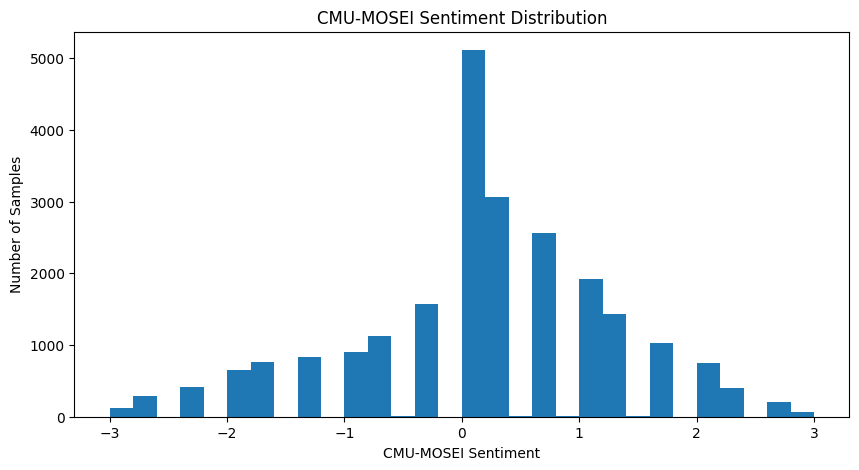

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["sentiment"],
    bins=30
)

plt.xlabel("CMU-MOSEI Sentiment")
plt.ylabel("Number of Samples")
plt.title("CMU-MOSEI Sentiment Distribution")

plt.show()

In [26]:
df["sentiment_normalized"] = df["sentiment"] / 3.0

print(
    df["sentiment_normalized"].describe()
)

count    23253.000000
mean         0.050493
std          0.370499
min         -1.000000
25%         -0.111111
50%          0.000000
75%          0.333333
max          1.000000
Name: sentiment_normalized, dtype: float64


In [27]:
print(
    "Minimum:",
    df["sentiment_normalized"].min()
)

print(
    "Maximum:",
    df["sentiment_normalized"].max()
)

assert df["sentiment_normalized"].min() >= -1
assert df["sentiment_normalized"].max() <= 1

print("Normalization validation passed.")

Minimum: -1.0
Maximum: 1.0
Normalization validation passed.


In [28]:
def sentiment_polarity(value):
    if value < 0:
        return "negative"
    elif value > 0:
        return "positive"
    else:
        return "neutral"


df["sentiment_polarity"] = (
    df["sentiment"]
    .apply(sentiment_polarity)
)

print(df["sentiment_polarity"].value_counts())

sentiment_polarity
positive    11471
negative     6682
neutral      5100
Name: count, dtype: int64


In [29]:
polarity_map = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

df["sentiment_polarity_numeric"] = (
    df["sentiment_polarity"]
    .map(polarity_map)
)

print(
    df["sentiment_polarity_numeric"].value_counts()
    .sort_index()
)

sentiment_polarity_numeric
-1     6682
 0     5100
 1    11471
Name: count, dtype: int64


In [30]:
display(
    df[
        [
            "text",
            "sentiment",
            "sentiment_normalized",
            "sentiment_polarity",
            "sentiment_polarity_numeric"
        ]
    ].head(20)
)

,text,sentiment,sentiment_normalized,sentiment_polarity,sentiment_polarity_numeric
0,writer i see that a writer is somebody who has...,1.000000,0.333333,positive,1
1,key is part of the people that we use to solve...,1.000000,0.333333,positive,1
2,businesses that we do they've been able to fin...,0.666667,0.222222,positive,1
3,operations key polymer brings a technical aspe...,0.000000,0.000000,neutral,0
4,internally we're a huge user of adhesives for ...,0.000000,0.000000,neutral,0
5,of things key brings those types of aspects to...,1.000000,0.333333,positive,1
6,solutions we have many new opportunities throu...,0.666667,0.222222,positive,1
7,introduction speaker dr erma jean sims sonoma ...,0.333333,0.111111,positive,1
8,it's important for teachers to understand thei...,1.000000,0.333333,positive,1
9,noncompliance can result in legal liability to...,0.000000,0.000000,neutral,0


In [31]:
sentiment_stats = {
    "count": int(df["sentiment"].count()),
    "mean": float(df["sentiment"].mean()),
    "std": float(df["sentiment"].std()),
    "min": float(df["sentiment"].min()),
    "max": float(df["sentiment"].max()),
    "median": float(df["sentiment"].median())
}

print(json.dumps(sentiment_stats, indent=4))

{
    "count": 23253,
    "mean": 0.15147866444224128,
    "std": 1.1114957846448181,
    "min": -3.0,
    "max": 3.0,
    "median": 0.0
}


In [32]:
polarity_percentages = (
    df["sentiment_polarity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)

print(polarity_percentages)

sentiment_polarity
positive    49.331
negative    28.736
neutral     21.933
Name: proportion, dtype: float64


In [33]:
print(
    df[
        ["token_count", "sentiment"]
    ].corr()
)

             token_count  sentiment
token_count     1.000000   0.040255
sentiment       0.040255   1.000000


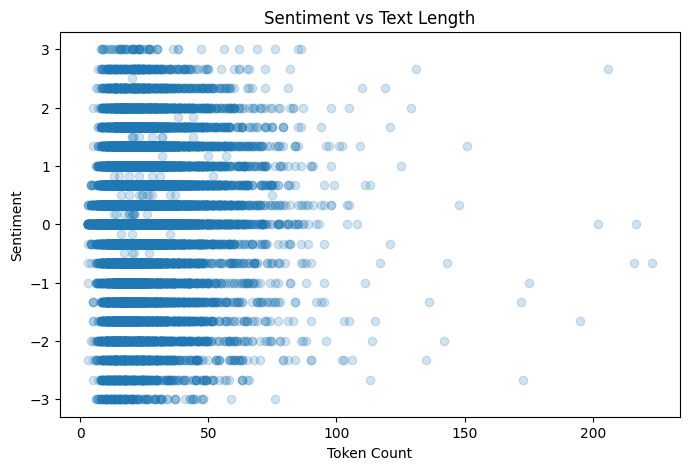

In [34]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["token_count"],
    df["sentiment"],
    alpha=0.2
)

plt.xlabel("Token Count")
plt.ylabel("Sentiment")
plt.title("Sentiment vs Text Length")

plt.show()

In [35]:
sentiment_df = df.copy()

print("Shape:", sentiment_df.shape)

Shape: (23253, 16)


In [36]:
sentiment_columns = [
    "sentiment",
    "sentiment_normalized",
    "sentiment_polarity",
    "sentiment_polarity_numeric"
]

print("Sentiment feature columns:")

for col in sentiment_columns:
    print("-", col)

Sentiment feature columns:
- sentiment
- sentiment_normalized
- sentiment_polarity
- sentiment_polarity_numeric


In [37]:
for col in sentiment_columns:
    print(
        col,
        "missing:",
        sentiment_df[col].isna().sum()
    )

sentiment missing: 0
sentiment_normalized missing: 0
sentiment_polarity missing: 0
sentiment_polarity_numeric missing: 0


In [38]:
assert sentiment_df["sentiment_normalized"].notna().all()
assert sentiment_df["sentiment_polarity_numeric"].notna().all()

print("Sentiment feature validation passed.")

Sentiment feature validation passed.


In [39]:
sentiment_df.to_pickle(SENTIMENT_PATH)

print("Saved successfully:")
print(SENTIMENT_PATH)

Saved successfully:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_features.pkl


In [40]:
reloaded_sentiment_df = pd.read_pickle(
    SENTIMENT_PATH
)

print(
    "Reloaded shape:",
    reloaded_sentiment_df.shape
)

print(
    "Columns:",
    reloaded_sentiment_df.columns.tolist()
)

Reloaded shape: (23253, 16)
Columns: ['segment_id', 'label_idx', 'start', 'end', 'text', 'token_count', 'sentiment', 'happiness', 'sadness', 'anger', 'surprise', 'disgust', 'fear', 'sentiment_normalized', 'sentiment_polarity', 'sentiment_polarity_numeric']


In [41]:
assert reloaded_sentiment_df.shape == sentiment_df.shape

assert (
    reloaded_sentiment_df["sentiment"]
    .equals(sentiment_df["sentiment"])
)

assert (
    reloaded_sentiment_df["sentiment_normalized"]
    .equals(sentiment_df["sentiment_normalized"])
)

assert (
    reloaded_sentiment_df["sentiment_polarity"]
    .equals(sentiment_df["sentiment_polarity"])
)

print("Reload integrity check PASSED.")

Reload integrity check PASSED.


In [42]:
metadata = {
    "dataset": "CMU-MOSEI",
    "feature_group": "Sentiment",
    "source": "CMU-MOSEI provided sentiment annotation",
    "original_sentiment_range": [-3, 3],
    "normalized_sentiment_range": [-1, 1],
    "normalization_formula": "sentiment / 3.0",
    "polarity_definition": {
        "negative": "< 0",
        "neutral": "= 0",
        "positive": "> 0"
    },
    "number_of_samples": int(len(sentiment_df)),
    "input_file": os.path.basename(READY_PATH),
    "output_file": os.path.basename(SENTIMENT_PATH)
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved:")
print(METADATA_PATH)

Metadata saved:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_features_metadata.json


In [43]:
print("=" * 60)
print("CMU-MOSEI SENTIMENT FEATURE PIPELINE COMPLETE")
print("=" * 60)

print("Samples:", len(sentiment_df))

print(
    "Original sentiment range:",
    sentiment_df["sentiment"].min(),
    "to",
    sentiment_df["sentiment"].max()
)

print(
    "Normalized range:",
    sentiment_df["sentiment_normalized"].min(),
    "to",
    sentiment_df["sentiment_normalized"].max()
)

print("\nPolarity distribution:")
print(sentiment_df["sentiment_polarity"].value_counts())

print("\nOutput:")
print(SENTIMENT_PATH)

print("\nMetadata:")
print(METADATA_PATH)

CMU-MOSEI SENTIMENT FEATURE PIPELINE COMPLETE
Samples: 23253
Original sentiment range: -3.0 to 3.0
Normalized range: -1.0 to 1.0

Polarity distribution:
sentiment_polarity
positive    11471
negative     6682
neutral      5100
Name: count, dtype: int64

Output:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_features.pkl

Metadata:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_sentiment_features_metadata.json
